In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.figure_factory as ff
import plotly.subplots as sp

In [22]:
df = pd.read_csv('data-task-10-insurance.csv')   
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [23]:
dtypes = df.dtypes
unique_values = df.nunique()
pd.DataFrame({'Data Type': dtypes, 'Unique Values': unique_values}).T

,age,sex,bmi,children,smoker,region,charges
Data Type,int64,str,float64,int64,str,str,float64
Unique Values,47,2,548,6,2,4,1337


In [24]:
df.info() # to get a concise summary of the DataFrame, including the number of non-null entries and data types for each column.

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [25]:
cat_cols = ["sex", "smoker", "region"]
df[cat_cols] = df[cat_cols].astype('category')

In [26]:
dtypes = df.dtypes
unique_values = df.nunique()
pd.DataFrame({'Data Type': dtypes, 'Unique Values': unique_values}).T

,age,sex,bmi,children,smoker,region,charges
Data Type,int64,category,float64,int64,category,category,float64
Unique Values,47,2,548,6,2,4,1337


In [27]:
df.select_dtypes("category")

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest
...,...,...,...
1333,male,no,northwest
1334,female,no,northeast
1335,female,no,southeast
1336,female,no,southwest


In [28]:
df.isnull()

,age,sex,bmi,children,smoker,region,charges
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
1333,False,False,False,False,False,False,False
1334,False,False,False,False,False,False,False
1335,False,False,False,False,False,False,False
1336,False,False,False,False,False,False,False


In [29]:
null = df.isnull().sum()
print(null)
ratio = null / len(df) * 100
print(ratio)

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
age         0.0
sex         0.0
bmi         0.0
children    0.0
smoker      0.0
region      0.0
charges     0.0
dtype: float64


In [30]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [31]:
num_col = df.select_dtypes("number").columns
num_col

Index(['age', 'bmi', 'children', 'charges'], dtype='str')

In [32]:
num_col = df.select_dtypes("number").columns
num_col
for col in num_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    print(Q1, Q3)
    IQR = Q3 - Q1
    print("IQR:", IQR)
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    print("Lower fence:", lower_fence, "Upper fence:", upper_fence)

27.0 51.0
IQR: 24.0
Lower fence: -9.0 Upper fence: 87.0
26.29625 34.69375
IQR: 8.3975
Lower fence: 13.7 Upper fence: 47.290000000000006
0.0 2.0
IQR: 2.0
Lower fence: -3.0 Upper fence: 5.0
4740.28715 16639.912515
IQR: 11899.625365
Lower fence: -13109.1508975 Upper fence: 34489.350562499996


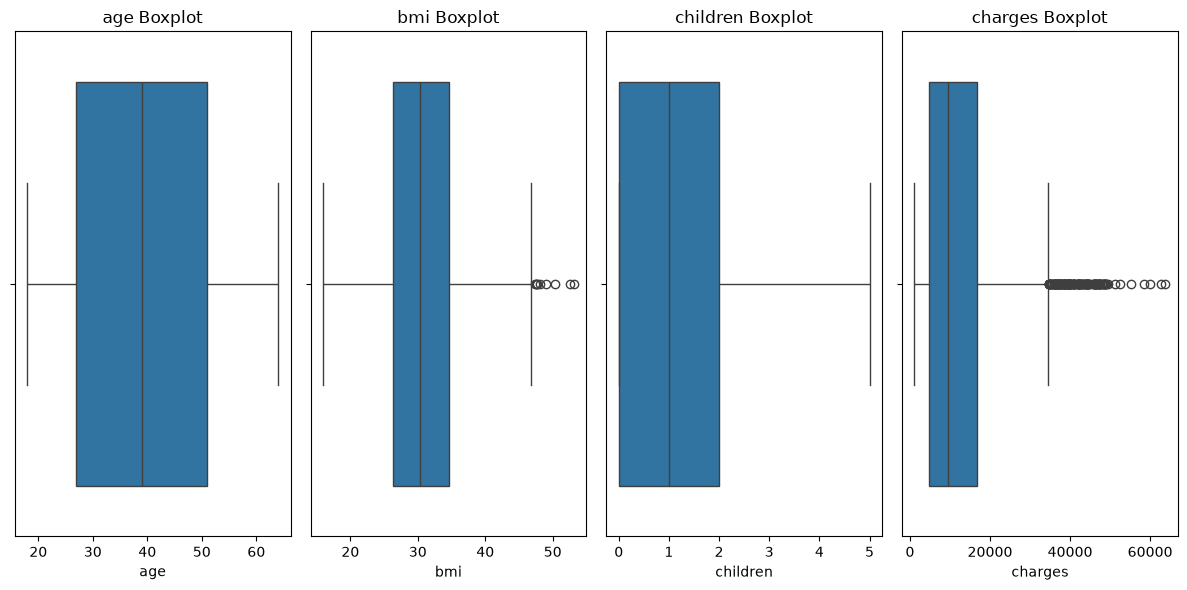

In [37]:
num_cols = df.select_dtypes("number").columns

plt.figure(figsize=(12, 6))

for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")

plt.tight_layout()
plt.show()

In [39]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1333    False
1334    False
1335    False
1336    False
1337    False
Length: 1338, dtype: bool

In [40]:
df.duplicated().sum()

np.int64(1)

In [41]:
df.drop_duplicates(inplace=True)

In [42]:
df.duplicated().sum()

np.int64(0)

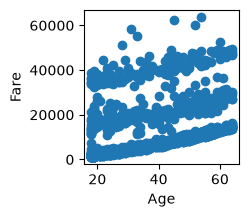

In [44]:
plt.figure(figsize=(2,2))
plt.scatter(df['age'], df['charges'])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

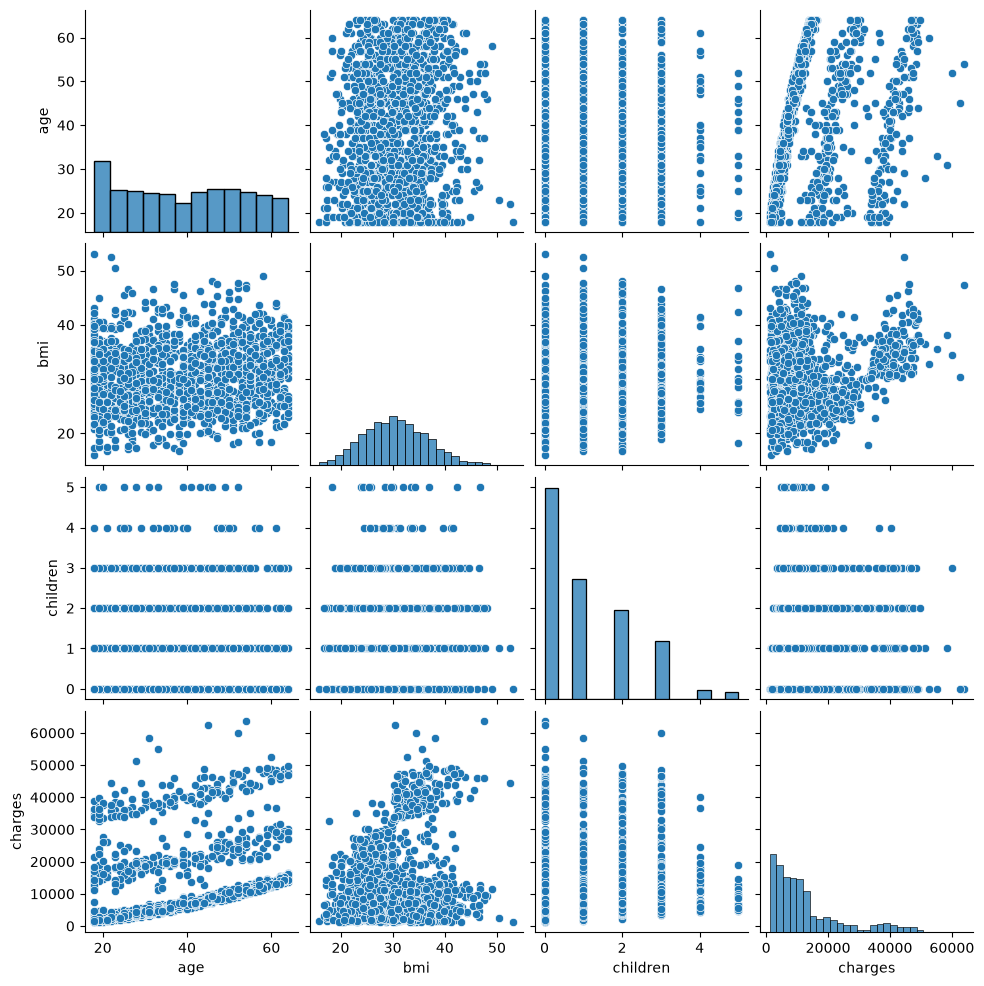

In [45]:
sns.pairplot(df)

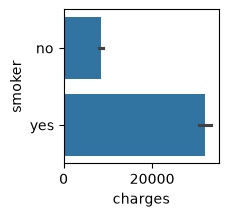

In [48]:
plt.figure(figsize=(2,2))
sns.barplot(x = "charges", y="smoker",data = df)
# sns.barplot(x = "charges", y="bmi",data = df)
plt.show()

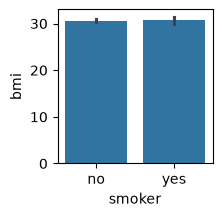

In [50]:
plt.figure(figsize=(2,2))
sns.barplot(x = "smoker", y="bmi",data = df)
plt.show()